<a href="https://colab.research.google.com/github/youssef12111/facial-emotion-recognition-ai/blob/main/Resnet_18_CK%2B_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CK+ Facial Emotion Recognition --- ResNet18
This notebook trains a deep learning model to recognise six facial emotions (angry, fear, happy, neutral, sad, surprise) using the Extended Cohn-Kanade (CK+) dataset, which is stored in Google Drive.
CK+ is a small, controlled laboratory dataset containing 245 training images and 97 test images. Because the images are already cropped around the face, no face detection was needed. The dataset has class imbalance, for example neutral has 66 training images while sadness only has 20, so weighted loss and a weighted sampler were used to handle this.
The model is a pretrained ResNet18 loaded with ImageNet weights. The backbone was kept frozen at first so only the new classification head learned in Phase 1. In Phase 2 the full network was unfrozen and fine-tuned at a much smaller learning rate to avoid overwriting the pretrained features. AdamW was used as the optimiser because its weight decay is more stable than standard Adam.
An ablation study was run to confirm that every design choice mattered, comparing the full pipeline against removing augmentation, using label smoothing only, and using Adam without weight decay.
A leave-one-subject-out (LOSO) evaluation was also performed across all 110 subjects to check that the model generalises to completely unseen individuals rather than just memorising faces it has seen before.
The final evaluation used test-time augmentation (TTA) with six passes per image. The notebook produces training curves, an ablation comparison chart, a confusion matrix, per-class F1 scores, and examples of correct and misclassified predictions.

In [ ]:
# libraries for the whoole notebook that is been used

import os
import re
import copy
import random
import shutil
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models  # includes pretrained models such as ResNet18

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import train_test_split
from PIL import Image

# Set a fixed random seed so results are more reproducible across runs.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True

# Automatically use GPU if available; otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Running on : {DEVICE}')
print(f'PyTorch    : {torch.__version__}')

Running on : cuda
PyTorch    : 2.10.0+cu128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


# Dataset paths
BASE_PATH  = Path('/content/drive/MyDrive/FER_JC/CK+/CK+')
TRAIN_PATH = BASE_PATH / 'train'
TEST_PATH  = BASE_PATH / 'test'

# Output directory for saving model results and training artefacts
DRIVE_OUTPUT = Path('/content/drive/MyDrive/FER_JC/CK+/outputs_resnet18_v1')
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)

# Define the emotion classes used in this experiment.
EMOTION_CLASSES = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
NUM_EMOTIONS    = len(EMOTION_CLASSES)
EMOTION_TO_IDX  = {e: i for i, e in enumerate(EMOTION_CLASSES)}

# Image and training settings
INPUT_SIZE          = 224   # Standard input resolution for ResNet18
BATCH_SIZE          = 32
DROPOUT_RATE        = 0.5   # Dropout applied in the final classification head
WEIGHT_DECAY        = 1e-2
EARLY_STOP_PATIENCE = 15

# Phase 1: train only the new fully connected layer while keeping
# the pretrained backbone frozen.
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3

# Phase 2: fine-tune the full network using a lower learning rate.
PHASE2_EPOCHS = 50
PHASE2_LR     = 1e-4

print(f'Emotion classes : {EMOTION_CLASSES}')
print(f'Input size      : {INPUT_SIZE}x{INPUT_SIZE}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Phase 1 epochs  : {PHASE1_EPOCHS}  (FC head only, backbone frozen)')
print(f'Phase 2 epochs  : {PHASE2_EPOCHS}  (full fine-tune)')
print(f'Drive output    : {DRIVE_OUTPUT}')

Emotion classes : ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
Input size      : 224x224
Batch size      : 32
Phase 1 epochs  : 10  (FC head only, backbone frozen)
Phase 2 epochs  : 50  (full fine-tune)
Drive output    : /content/drive/MyDrive/FER_JC/CK+/outputs_resnet18_v1


In [ ]:


IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def inspect_split(split_path, label):
    # Display the number of valid image files in each class folder.
    print(f'\n{label} folder: {split_path}')

    if not split_path.exists():
        print('  ERROR: folder does not exist!')
        return

    total = 0
    for subdir in sorted(split_path.iterdir()):
        if subdir.is_dir():
            imgs = [f for f in subdir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
            print(f'  {subdir.name:<15}: {len(imgs)} images')
            total += len(imgs)

    print(f'  Total: {total} images')

inspect_split(TRAIN_PATH, 'TRAIN')
inspect_split(TEST_PATH, 'TEST')


TRAIN folder: /content/drive/MyDrive/FER_JC/CK+/CK+/train
  anger          : 31 images
  fear           : 22 images
  happy          : 48 images
  neutral        : 66 images
  sadness        : 20 images
  surprise       : 58 images
  Total: 245 images

TEST folder: /content/drive/MyDrive/FER_JC/CK+/CK+/test
  anger          : 14 images
  fear           : 7 images
  happy          : 21 images
  neutral        : 23 images
  sadness        : 8 images
  surprise       : 24 images
  Total: 97 images


In [ ]:


def extract_subject_id(filename: str) -> str:
    # Extract the subject ID from CK+ filenames such as S005_001_00000011.png.
    match = re.match(r'(S\d+)', filename)
    return match.group(1) if match else 'unknown'


def collect_ck_paths(split_folder, emotion_classes, verbose=True):
    """
    Collect image paths, numeric labels, and subject IDs from each class folder.
    Any class not included in emotion_classes is ignored.
    """
    all_paths = []
    all_labels = []
    all_subjects = []
    skipped = []

    if not split_folder.exists():
        print(f'ERROR: {split_folder} does not exist')
        return [], [], []

    for subdir in sorted(split_folder.iterdir()):
        if not subdir.is_dir():
            continue

        class_name = subdir.name.lower()
        if class_name not in emotion_classes:
            skipped.append(subdir.name)
            continue

        label = emotion_classes.index(class_name)

        for img_file in sorted(subdir.iterdir()):
            if img_file.suffix.lower() in IMAGE_EXTS:
                all_paths.append(str(img_file))
                all_labels.append(label)
                all_subjects.append(extract_subject_id(img_file.name))

    if verbose:
        print(f'Loaded {len(all_paths)} images from {split_folder.name}/')
        if skipped:
            print(f'  Skipped (not in 6-class set): {skipped}')

    return all_paths, all_labels, all_subjects


train_paths, train_labels, train_subjects = collect_ck_paths(
    TRAIN_PATH, EMOTION_CLASSES
)
test_paths, test_labels, test_subjects = collect_ck_paths(
    TEST_PATH, EMOTION_CLASSES
)

# Check whether the same subject appears in both training and test sets.
train_subject_set = set(train_subjects)
test_subject_set = set(test_subjects)
overlapping = train_subject_set & test_subject_set

print(f'\nSubject ID analysis:')
print(f'  Unique subjects in train : {len(train_subject_set)}')
print(f'  Unique subjects in test  : {len(test_subject_set)}')
print(f'  Overlapping subjects     : {len(overlapping)}')

if overlapping:
    print('  WARNING: Subject-level leakage detected!')
    print('  Same subjects appear in both splits - results will be optimistic.')
    print('  LOSO evaluation in Cell 17 provides a leakage-free estimate.')
else:
    print('  No leakage. Train/test subjects are fully disjoint.')

# Print the class distribution for both splits.
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print(f'\n{"Class":<12} {"Train":>8} {"Test":>8}')
print('-' * 30)
for i, cls in enumerate(EMOTION_CLASSES):
    print(f'{cls:<12} {train_counts.get(i, 0):>8} {test_counts.get(i, 0):>8}')

Loaded 245 images from train/
Loaded 97 images from test/

Subject ID analysis:
  Unique subjects in train : 93
  Unique subjects in test  : 61
  Overlapping subjects     : 44
  Same subjects appear in both splits - results will be optimistic.
  LOSO evaluation in Cell 17 provides a leakage-free estimate.

Class           Train     Test
------------------------------
anger              31       14
fear               22        7
happy              48       21
neutral            66       23
sadness            20        8
surprise           58       24


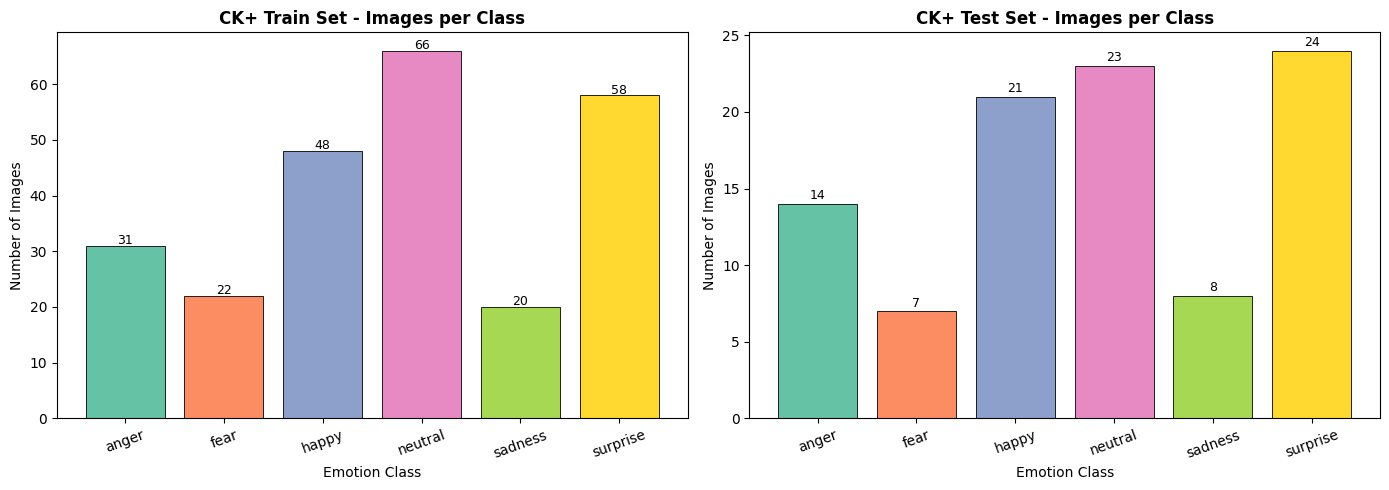

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split_label, counts) in zip(
    axes,
    [('Train', train_counts), ('Test', test_counts)]
):
    values = [counts.get(i, 0) for i in range(NUM_EMOTIONS)]

    bars = ax.bar(
        EMOTION_CLASSES,
        values,
        color=sns.color_palette('Set2', NUM_EMOTIONS),
        edgecolor='black',
        linewidth=0.6
    )

    ax.set_title(f'CK+ {split_label} Set - Images per Class',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)

    # Add the image count above each bar for easier comparison.
    for bar, count in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count + 0.3,
            str(count),
            ha='center',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('resnet18_ckp_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

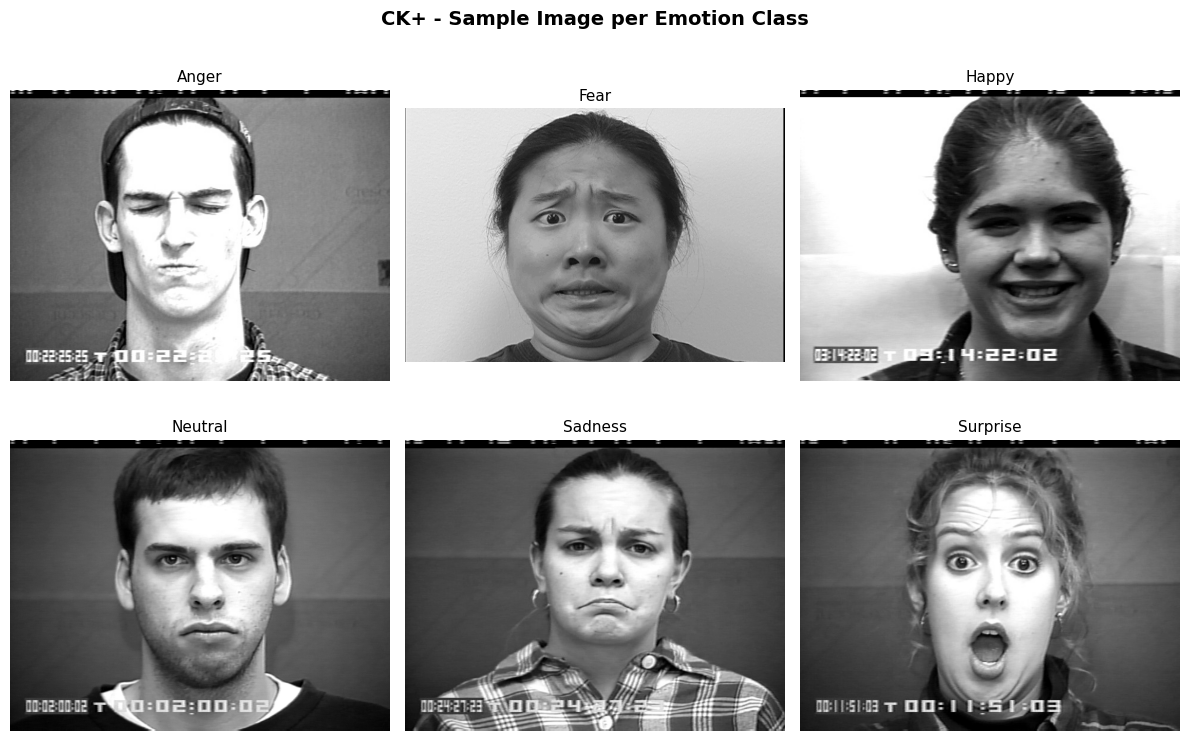

In [ ]:



fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('CK+ - Sample Image per Emotion Class',
             fontsize=14, fontweight='bold')

for ax, (i, emotion) in zip(axes.flatten(), enumerate(EMOTION_CLASSES)):
    class_paths = [p for p, l in zip(train_paths, train_labels) if l == i]
    if not class_paths:
        ax.set_visible(False)
        continue
    img = Image.open(random.choice(class_paths)).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion.capitalize(), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('resnet18_ckp_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


# Training transforms include light augmentation to improve generalisation.
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transforms keep the images consistent without augmentation.
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test-time augmentation applies mild geometric changes only.
tta_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Golden augmentation pipeline loaded.')
print('train_transforms : flip + rotation(15) + affine + colorjitter + ImageNet norm')
print('val_transforms   : resize + ImageNet norm only')
print('tta_transforms   : flip + rotation(10) + light affine + ImageNet norm')

Golden augmentation pipeline loaded.
train_transforms : flip + rotation(15) + affine + colorjitter + ImageNet norm
val_transforms   : resize + ImageNet norm only
tta_transforms   : flip + rotation(10) + light affine + ImageNet norm


In [ ]:
class EmotionDataset(Dataset):
    """Dataset class for loading emotion images and labels."""

    def __init__(self, image_paths, class_labels, transform=None):
        self.image_paths = list(image_paths)
        self.class_labels = list(class_labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Convert to RGB so the images match the 3-channel input expected by ResNet18.
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.class_labels[idx]


# Create an 85% training split and a 15% validation split.
train_img_paths, val_img_paths, train_lbl, val_lbl = train_test_split(
    train_paths,
    train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=RANDOM_SEED
)

print(f'Split sizes:')
print(f'  Train : {len(train_img_paths)}')
print(f'  Val   : {len(val_img_paths)}')
print(f'  Test  : {len(test_paths)}')

# Build dataset objects for training, validation, and testing.
training_dataset = EmotionDataset(
    train_img_paths, train_lbl, transform=train_transforms
)
validation_dataset = EmotionDataset(
    val_img_paths, val_lbl, transform=val_transforms
)
test_dataset = EmotionDataset(
    test_paths, test_labels, transform=val_transforms
)

# Use weighted sampling to reduce the effect of class imbalance during training.
emotion_counts = Counter(train_lbl)
sampling_weights = [1.0 / emotion_counts[l] for l in train_lbl]
balanced_sampler = WeightedRandomSampler(
    weights=sampling_weights,
    num_samples=len(sampling_weights),
    replacement=True
)

train_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Split sizes:
  Train : 208
  Val   : 37
  Test  : 97
Train batches: 7 | Val batches: 2


In [ ]:
def get_resnet18_model(num_classes=6, dropout_rate=0.5, freeze_backbone=True):
    """
    Build a ResNet18 model with a custom classification head.
    """
    model = models.resnet18(weights='IMAGENET1K_V1')

    # Freeze the pretrained backbone during the first training phase if required.
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the original fully connected layer with a new head for emotion classification.
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(num_ftrs, num_classes)
    )

    return model


def unfreeze_backbone(model):
    """Make all model parameters trainable for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    print('All layers unfrozen for full fine-tuning (Phase 2)')


# Build the model with the backbone frozen for Phase 1 training.
emotion_model = get_resnet18_model(
    num_classes=NUM_EMOTIONS,
    dropout_rate=DROPOUT_RATE,
    freeze_backbone=True
).to(DEVICE)

total_params = sum(p.numel() for p in emotion_model.parameters())
trainable_params = sum(
    p.numel() for p in emotion_model.parameters() if p.requires_grad
)

print(f'Total parameters      : {total_params:,}')
print(f'Trainable (Phase 1)   : {trainable_params:,}  (FC head only)')
print(f'Frozen    (Phase 1)   : {total_params - trainable_params:,}  (backbone)')

Total parameters      : 11,179,590
Trainable (Phase 1)   : 3,078  (FC head only)
Frozen    (Phase 1)   : 11,176,512  (backbone)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights from the training labels to reduce the impact of class imbalance.
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert the weights to a tensor so they can be used by the loss function on the selected device.
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

# Define the weighted loss functions used during training.
criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion_smooth = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

print(f'Loss function: Weighted CrossEntropyLoss')
print('-' * 40)
for cls, weight in zip(EMOTION_CLASSES, weights):
    print(f'  Weight for {cls:<10}: {weight:.4f}')

Loss function: Weighted CrossEntropyLoss
----------------------------------------
  Weight for anger     : 1.3172
  Weight for fear      : 1.8561
  Weight for happy     : 0.8507
  Weight for neutral   : 0.6187
  Weight for sadness   : 2.0417
  Weight for surprise  : 0.7040


In [ ]:
def run_training_epoch(model, data_loader, loss_fn, optimiser):
    """Run one full training epoch."""
    model.train()
    epoch_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimiser.zero_grad()
        preds = model(batch_images)
        loss = loss_fn(preds, batch_labels)
        loss.backward()

        # Clip gradients to reduce the risk of unstable updates.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimiser.step()

        epoch_loss += loss.item() * batch_images.size(0)
        correct_preds += (preds.argmax(1) == batch_labels).sum().item()
        total_samples += batch_images.size(0)

    return epoch_loss / total_samples, correct_preds / total_samples


def run_evaluation(model, data_loader, loss_fn):
    """Evaluate the model and return loss, accuracy, and macro F1-score."""
    model.eval()
    epoch_loss = 0.0
    correct_preds = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            outputs = model(batch_images)
            loss = loss_fn(outputs, batch_labels)

            epoch_loss += loss.item() * batch_images.size(0)
            batch_preds = outputs.argmax(1)
            correct_preds += (batch_preds == batch_labels).sum().item()
            total_samples += batch_images.size(0)

            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss / total_samples, correct_preds / total_samples, macro_f1


def predict_with_tta(model, dataset, num_augmented_passes=6):
    """
    Apply test-time augmentation and average the prediction scores
    across multiple passes for each image.
    """
    model.eval()
    final_preds = []
    ground_truth = []

    for img_path, true_label in zip(dataset.image_paths, dataset.class_labels):
        original_img = Image.open(img_path).convert('RGB')
        softmax_out = []

        # First pass uses the standard validation transform.
        t = val_transforms(original_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            softmax_out.append(torch.softmax(model(t), dim=1))

        # Additional passes apply light augmentation before prediction.
        for _ in range(num_augmented_passes):
            t = tta_transforms(original_img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                softmax_out.append(torch.softmax(model(t), dim=1))

        avg_out = torch.stack(softmax_out).mean(dim=0)
        final_preds.append(avg_out.argmax(dim=1).item())
        ground_truth.append(true_label)

    return np.array(final_preds), np.array(ground_truth)


print('Training and evaluation functions defined.')

Training and evaluation functions defined.


In [ ]:
# Only the FC head parameters are updated during Phase 1 training.
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, emotion_model.parameters()),
    lr=PHASE1_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_phase1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase1,
    mode='max',
    factor=0.1,
    patience=5
)

best_val_f1_p1 = 0.0
no_improve_p1 = 0

history_p1 = {
    'train_acc': [],
    'val_acc': [],
    'val_f1': [],
    'train_loss': [],
    'val_loss': []
}

print('PHASE 1 - Training FC head only (backbone frozen)')
print(f'Epochs: {PHASE1_EPOCHS}  |  LR: {PHASE1_LR}  |  WD: {WEIGHT_DECAY}')
print('-' * 75)

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = run_training_epoch(
        emotion_model, train_loader, criterion, optimizer_phase1
    )
    va_loss, va_acc, va_f1 = run_evaluation(
        emotion_model, val_loader, criterion
    )

    history_p1['train_acc'].append(tr_acc)
    history_p1['val_acc'].append(va_acc)
    history_p1['val_f1'].append(va_f1)
    history_p1['train_loss'].append(tr_loss)
    history_p1['val_loss'].append(va_loss)

    # Update the learning rate when validation accuracy stops improving.
    scheduler_phase1.step(va_acc)

    # Save the best Phase 1 model based on validation macro F1-score.
    if va_f1 > best_val_f1_p1:
        best_val_f1_p1 = va_f1
        torch.save(emotion_model.state_dict(), 'best_resnet18_p1.pth')
        marker = '<<'
    else:
        marker = ''

    current_lr = optimizer_phase1.param_groups[0]['lr']
    print(
        f'P1 Epoch {epoch:2d}/{PHASE1_EPOCHS}  '
        f'train acc {tr_acc:.4f}  loss {tr_loss:.4f}  |  '
        f'val acc {va_acc:.4f}  f1 {va_f1:.4f}  loss {va_loss:.4f}  '
        f'lr {current_lr:.1e}  {marker}'
    )

print(f'\nPhase 1 complete. Best val macro F1: {best_val_f1_p1:.4f}')

PHASE 1 - Training FC head only (backbone frozen)
Epochs: 10  |  LR: 0.001  |  WD: 0.01
---------------------------------------------------------------------------
P1 Epoch  1/10  train acc 0.2019  loss 1.9643  |  val acc 0.1081  f1 0.0812  loss 2.3047  lr 1.0e-03  <<
P1 Epoch  2/10  train acc 0.1635  loss 1.8752  |  val acc 0.1892  f1 0.1708  loss 1.8766  lr 1.0e-03  <<
P1 Epoch  3/10  train acc 0.2308  loss 1.8275  |  val acc 0.2162  f1 0.2135  loss 1.7933  lr 1.0e-03  <<
P1 Epoch  4/10  train acc 0.2596  loss 1.6595  |  val acc 0.0811  f1 0.0270  loss 1.8782  lr 1.0e-03  
P1 Epoch  5/10  train acc 0.2500  loss 1.7211  |  val acc 0.1081  f1 0.0579  loss 2.0249  lr 1.0e-03  
P1 Epoch  6/10  train acc 0.2548  loss 1.6075  |  val acc 0.0270  f1 0.0175  loss 1.7972  lr 1.0e-03  
P1 Epoch  7/10  train acc 0.2212  loss 1.6956  |  val acc 0.1622  f1 0.1468  loss 1.6774  lr 1.0e-03  
P1 Epoch  8/10  train acc 0.3221  loss 1.6100  |  val acc 0.2703  f1 0.2280  loss 1.6674  lr 1.0e-03  <<
P1 E

In [ ]:
# Load the best Phase 1 model before starting full fine-tuning.
emotion_model.load_state_dict(torch.load('best_resnet18_p1.pth'))
unfreeze_backbone(emotion_model)

total_trainable_p2 = sum(
    p.numel() for p in emotion_model.parameters() if p.requires_grad
)
print(f'Trainable parameters (Phase 2): {total_trainable_p2:,}  (all layers)')

# Use a lower learning rate when fine-tuning the full network.
optimizer_phase2 = optim.AdamW(
    emotion_model.parameters(),
    lr=PHASE2_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2,
    mode='max',
    factor=0.1,
    patience=5
)

best_val_f1_p2 = 0.0
no_improve_p2 = 0

history_p2 = {
    'train_acc': [],
    'val_acc': [],
    'val_f1': [],
    'train_loss': [],
    'val_loss': []
}

print(f'\nPHASE 2 - Full fine-tuning (all layers)')
print(f'Epochs: {PHASE2_EPOCHS}  |  LR: {PHASE2_LR}  |  WD: {WEIGHT_DECAY}')
print(f'Early stopping patience: {EARLY_STOP_PATIENCE}')
print('-' * 75)

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = run_training_epoch(
        emotion_model, train_loader, criterion, optimizer_phase2
    )
    va_loss, va_acc, va_f1 = run_evaluation(
        emotion_model, val_loader, criterion
    )

    history_p2['train_acc'].append(tr_acc)
    history_p2['val_acc'].append(va_acc)
    history_p2['val_f1'].append(va_f1)
    history_p2['train_loss'].append(tr_loss)
    history_p2['val_loss'].append(va_loss)

    scheduler_phase2.step(va_acc)

    # Save the best model based on validation macro F1-score.
    if va_f1 > best_val_f1_p2:
        best_val_f1_p2 = va_f1
        torch.save(emotion_model.state_dict(), 'best_resnet18_final.pth')
        no_improve_p2 = 0
        marker = '<<'
    else:
        no_improve_p2 += 1
        marker = ''

    current_lr = optimizer_phase2.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(
            f'P2 Epoch {epoch:2d}/{PHASE2_EPOCHS}  '
            f'train acc {tr_acc:.4f}  loss {tr_loss:.4f}  |  '
            f'val acc {va_acc:.4f}  f1 {va_f1:.4f}  loss {va_loss:.4f}  '
            f'lr {current_lr:.1e}  {marker}'
        )

    # Stop training if validation performance does not improve for several epochs.
    if no_improve_p2 >= EARLY_STOP_PATIENCE:
        print(f'Early stopping triggered at Phase 2 epoch {epoch}')
        break

print(f'\nPhase 2 complete. Best val macro F1: {best_val_f1_p2:.4f}')
shutil.copy(
    'best_resnet18_final.pth',
    str(DRIVE_OUTPUT / 'best_resnet18_final_backup.pth')
)
print('Best model backed up to Drive.')

All layers unfrozen for full fine-tuning (Phase 2)
Trainable parameters (Phase 2): 11,179,590  (all layers)

PHASE 2 - Full fine-tuning (all layers)
Epochs: 50  |  LR: 0.0001  |  WD: 0.01
Early stopping patience: 15
---------------------------------------------------------------------------
P2 Epoch  1/50  train acc 0.3990  loss 1.4948  |  val acc 0.4595  f1 0.3658  loss 1.4841  lr 1.0e-04  <<
P2 Epoch  2/50  train acc 0.5769  loss 1.0576  |  val acc 0.5135  f1 0.3704  loss 1.4050  lr 1.0e-04  <<
P2 Epoch  3/50  train acc 0.6538  loss 0.8465  |  val acc 0.5946  f1 0.4985  loss 1.2699  lr 1.0e-04  <<
P2 Epoch  5/50  train acc 0.7885  loss 0.5160  |  val acc 0.5135  f1 0.4002  loss 1.6253  lr 1.0e-04  
P2 Epoch  6/50  train acc 0.7885  loss 0.4632  |  val acc 0.6757  f1 0.5895  loss 1.2512  lr 1.0e-04  <<
P2 Epoch 10/50  train acc 0.8894  loss 0.2104  |  val acc 0.7027  f1 0.5048  loss 1.7800  lr 1.0e-04  
P2 Epoch 13/50  train acc 0.9471  loss 0.0904  |  val acc 0.7568  f1 0.6023  loss 

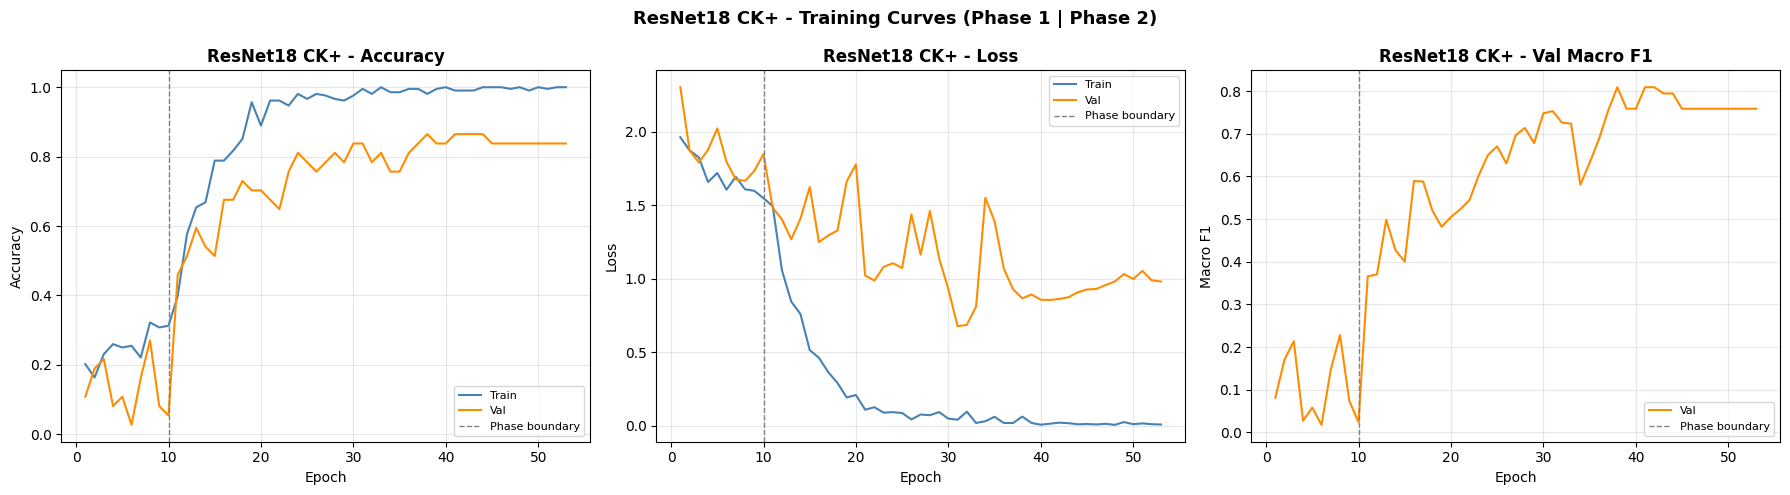

In [ ]:
p1_len = len(history_p1['train_acc'])
p2_len = len(history_p2['train_acc'])
total_epochs = p1_len + p2_len

# Combine the training history from both phases into one set of curves.
combined = {
    'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
    'val_acc': history_p1['val_acc'] + history_p2['val_acc'],
    'val_f1': history_p1['val_f1'] + history_p2['val_f1'],
    'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
    'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
}

epochs_axis = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'ResNet18 CK+ - Training Curves (Phase 1 | Phase 2)',
    fontsize=13,
    fontweight='bold'
)

for ax, y_train, y_val, title, ylabel in zip(
    axes,
    [combined['train_acc'], combined['train_loss'], [None] * total_epochs],
    [combined['val_acc'], combined['val_loss'], combined['val_f1']],
    ['Accuracy', 'Loss', 'Val Macro F1'],
    ['Accuracy', 'Loss', 'Macro F1']
):
    if y_train[0] is not None:
        ax.plot(epochs_axis, y_train, label='Train', color='steelblue')

    ax.plot(epochs_axis, y_val, label='Val', color='darkorange')

    # Mark the point where training switches from Phase 1 to Phase 2.
    ax.axvline(
        x=p1_len,
        color='gray',
        linestyle='--',
        linewidth=1,
        label='Phase boundary'
    )

    ax.set_title(f'ResNet18 CK+ - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet18_ckp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Running experiment: A: No augmentation
All layers unfrozen for full fine-tuning (Phase 2)
  Best val macro F1: 0.7224
Running experiment: B: Label smoothing CE
All layers unfrozen for full fine-tuning (Phase 2)
  Best val macro F1: 0.6367
Running experiment: C: Adam (no weight decay)
All layers unfrozen for full fine-tuning (Phase 2)
  Best val macro F1: 0.6287

=== EXPERIMENT COMPARISON ===
                     label  best_val_f1
Baseline (golden pipeline)     0.809171
        A: No augmentation     0.722441
     B: Label smoothing CE     0.636653
 C: Adam (no weight decay)     0.628704


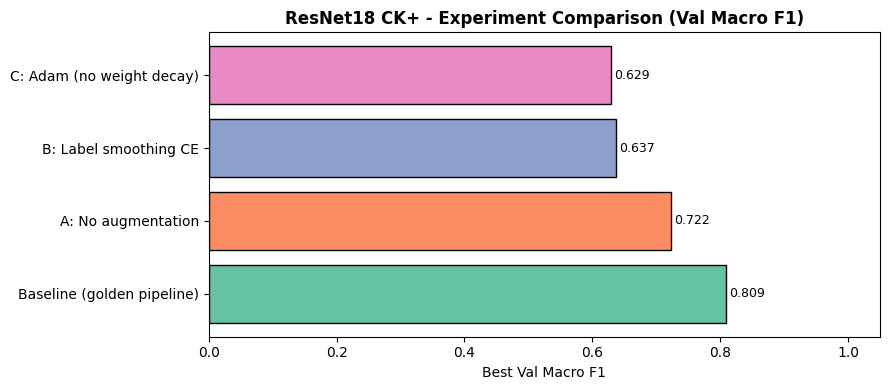

In [ ]:
COMPARE_EPOCHS = 30
COMPARE_PATIENCE = 10

experiments = [
    {
        'name': 'A_no_augmentation',
        'label': 'A: No augmentation',
        'aug': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'loss': nn.CrossEntropyLoss(),
        'opt_fn': lambda p: optim.AdamW(p, lr=PHASE2_LR, weight_decay=WEIGHT_DECAY),
    },
    {
        'name': 'B_label_smoothing',
        'label': 'B: Label smoothing CE',
        'aug': train_transforms,
        'loss': criterion_smooth,
        'opt_fn': lambda p: optim.AdamW(p, lr=PHASE2_LR, weight_decay=WEIGHT_DECAY),
    },
    {
        'name': 'C_adam_no_wd',
        'label': 'C: Adam (no weight decay)',
        'aug': train_transforms,
        'loss': nn.CrossEntropyLoss(),
        'opt_fn': lambda p: optim.Adam(p, lr=PHASE2_LR),
    },
]

experiment_results = [
    {'label': 'Baseline (golden pipeline)', 'best_val_f1': best_val_f1_p2}
]

for exp in experiments:
    print(f"Running experiment: {exp['label']}")

    # Rebuild the datasets using the transform for the current experiment.
    exp_tr = EmotionDataset(train_img_paths, train_lbl, transform=exp['aug'])
    exp_va = EmotionDataset(val_img_paths, val_lbl, transform=val_transforms)

    exp_sampler = WeightedRandomSampler(
        [1.0 / emotion_counts[l] for l in train_lbl],
        len(train_lbl),
        replacement=True
    )

    exp_tr_loader = DataLoader(
        exp_tr,
        batch_size=BATCH_SIZE,
        sampler=exp_sampler,
        num_workers=2,
        pin_memory=True
    )
    exp_va_loader = DataLoader(
        exp_va,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Start each experiment from the best Phase 1 model, then fine-tune all layers.
    exp_model = get_resnet18_model(
        num_classes=NUM_EMOTIONS,
        dropout_rate=DROPOUT_RATE,
        freeze_backbone=True
    ).to(DEVICE)
    exp_model.load_state_dict(torch.load('best_resnet18_p1.pth'))
    unfreeze_backbone(exp_model)

    exp_opt = exp['opt_fn'](exp_model.parameters())
    exp_sched = optim.lr_scheduler.ReduceLROnPlateau(
        exp_opt,
        mode='max',
        factor=0.1,
        patience=5
    )

    best_f1_exp = 0.0
    no_improve_ex = 0

    for epoch in range(1, COMPARE_EPOCHS + 1):
        run_training_epoch(exp_model, exp_tr_loader, exp['loss'], exp_opt)
        _, va_acc_ex, va_f1_ex = run_evaluation(
            exp_model, exp_va_loader, exp['loss']
        )
        exp_sched.step(va_acc_ex)

        if va_f1_ex > best_f1_exp:
            best_f1_exp = va_f1_ex
            no_improve_ex = 0
        else:
            no_improve_ex += 1

        if no_improve_ex >= COMPARE_PATIENCE:
            break

    experiment_results.append({'label': exp['label'], 'best_val_f1': best_f1_exp})
    print(f"  Best val macro F1: {best_f1_exp:.4f}")

    del exp_model
    torch.cuda.empty_cache()

# Create a comparison table sorted by validation macro F1-score.
compare_df = pd.DataFrame(experiment_results).sort_values(
    'best_val_f1', ascending=False
).reset_index(drop=True)

print('\n=== EXPERIMENT COMPARISON ===')
print(compare_df.to_string(index=False))

# Plot the comparison results as a horizontal bar chart.
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    compare_df['label'],
    compare_df['best_val_f1'],
    color=sns.color_palette('Set2', len(compare_df)),
    edgecolor='black'
)
ax.set_title(
    'ResNet18 CK+ - Experiment Comparison (Val Macro F1)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Best Val Macro F1')
ax.set_xlim(0, 1.05)

for i, val in enumerate(compare_df['best_val_f1']):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('resnet18_ckp_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Combine all available images for subject-independent LOSO evaluation.
all_paths_loso = train_paths + test_paths
all_labels_loso = train_labels + test_labels
all_subjects_loso = train_subjects + test_subjects

unique_subjects = sorted(set(all_subjects_loso))
print(f'Total subjects for LOSO: {len(unique_subjects)}')
print(f'Total images            : {len(all_paths_loso)}')

LOSO_EPOCHS = 25
LOSO_PATIENCE = 8

loso_f1_scores = []
loso_accuracies = []

print(f'\nRunning LOSO ({len(unique_subjects)} folds x max {LOSO_EPOCHS} epochs)...')
print('-' * 70)

for fold_idx, held_out_subject in enumerate(unique_subjects):
    fold_tr_idx = [i for i, s in enumerate(all_subjects_loso) if s != held_out_subject]
    fold_te_idx = [i for i, s in enumerate(all_subjects_loso) if s == held_out_subject]

    if not fold_te_idx:
        continue

    fold_tr_paths = [all_paths_loso[i] for i in fold_tr_idx]
    fold_tr_labels = [all_labels_loso[i] for i in fold_tr_idx]
    fold_te_paths = [all_paths_loso[i] for i in fold_te_idx]
    fold_te_labels = [all_labels_loso[i] for i in fold_te_idx]

    fold_tr_ds = EmotionDataset(
        fold_tr_paths, fold_tr_labels, transform=train_transforms
    )
    fold_te_ds = EmotionDataset(
        fold_te_paths, fold_te_labels, transform=val_transforms
    )

    fold_counts = Counter(fold_tr_labels)
    fold_weights = [
        1.0 / fold_counts[l] if fold_counts[l] > 0 else 0.0
        for l in fold_tr_labels
    ]
    fold_sampler = WeightedRandomSampler(
        fold_weights,
        len(fold_weights),
        replacement=True
    )

    fold_tr_loader = DataLoader(
        fold_tr_ds,
        batch_size=BATCH_SIZE,
        sampler=fold_sampler,
        num_workers=2,
        pin_memory=True
    )
    fold_te_loader = DataLoader(
        fold_te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Start each fold from the Phase 1 model, then fine-tune all layers.
    fold_model = get_resnet18_model(
        num_classes=NUM_EMOTIONS,
        dropout_rate=DROPOUT_RATE,
        freeze_backbone=True
    ).to(DEVICE)
    fold_model.load_state_dict(torch.load('best_resnet18_p1.pth'))
    unfreeze_backbone(fold_model)

    fold_opt = optim.AdamW(
        fold_model.parameters(),
        lr=PHASE2_LR,
        weight_decay=WEIGHT_DECAY
    )
    fold_sched = optim.lr_scheduler.ReduceLROnPlateau(
        fold_opt,
        mode='max',
        factor=0.1,
        patience=4
    )

    best_state = copy.deepcopy(fold_model.state_dict())
    best_f1_fold = 0.0
    no_improve = 0

    for epoch in range(1, LOSO_EPOCHS + 1):
        run_training_epoch(fold_model, fold_tr_loader, criterion, fold_opt)
        _, te_acc, te_f1 = run_evaluation(fold_model, fold_te_loader, criterion)
        fold_sched.step(te_acc)

        if te_f1 > best_f1_fold:
            best_f1_fold = te_f1
            best_state = copy.deepcopy(fold_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= LOSO_PATIENCE:
            break

    fold_model.load_state_dict(best_state)
    _, fold_acc, fold_f1 = run_evaluation(fold_model, fold_te_loader, criterion)

    loso_f1_scores.append(fold_f1)
    loso_accuracies.append(fold_acc)

    print(
        f'Fold {fold_idx+1:3d}/{len(unique_subjects)}  '
        f'subject={held_out_subject}  n_test={len(fold_te_paths)}  '
        f'acc={fold_acc:.4f}  macro_f1={fold_f1:.4f}'
    )

    del fold_model
    torch.cuda.empty_cache()

print(f'\n=== LOSO RESULTS ===')
print(f'Mean Macro F1 : {np.mean(loso_f1_scores):.4f} ± {np.std(loso_f1_scores):.4f}')
print(f'Mean Accuracy : {np.mean(loso_accuracies):.4f} ± {np.std(loso_accuracies):.4f}')

Total subjects for LOSO: 110
Total images            : 342

Running LOSO (110 folds x max 25 epochs)...
----------------------------------------------------------------------
All layers unfrozen for full fine-tuning (Phase 2)
Fold   1/110  subject=S005  n_test=1  acc=0.0000  macro_f1=0.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   2/110  subject=S010  n_test=4  acc=1.0000  macro_f1=1.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   3/110  subject=S011  n_test=6  acc=1.0000  macro_f1=1.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   4/110  subject=S014  n_test=5  acc=1.0000  macro_f1=1.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   5/110  subject=S022  n_test=4  acc=1.0000  macro_f1=1.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   6/110  subject=S026  n_test=5  acc=1.0000  macro_f1=1.0000
All layers unfrozen for full fine-tuning (Phase 2)
Fold   7/110  subject=S028  n_test=2  acc=1.0000  macro_f1=1.0000
All la

In [ ]:
emotion_model.load_state_dict(torch.load('best_resnet18_final.pth'))
emotion_model.eval()

print('Loaded the best Phase 2 checkpoint.')
print('Running test-time augmentation (7 passes per image)...')

predicted_labels, true_labels_np = predict_with_tta(
    emotion_model,
    test_dataset,
    num_augmented_passes=6
)

test_accuracy = (predicted_labels == true_labels_np).mean()
print(f'\nTest Accuracy with TTA: {test_accuracy * 100:.2f}%')

class_indices = list(range(NUM_EMOTIONS))

report_text = classification_report(
    true_labels_np,
    predicted_labels,
    labels=class_indices,
    target_names=EMOTION_CLASSES,
    digits=4
)
report_dict = classification_report(
    true_labels_np,
    predicted_labels,
    labels=class_indices,
    target_names=EMOTION_CLASSES,
    output_dict=True
)

print('\nClassification Report - CK+ Test Set (ResNet18)')
print('=' * 60)
print(report_text)

# Save the classification report so it can be reused in the final report or appendix.
with open('resnet18_ckp_classification_report.txt', 'w') as f:
    f.write(report_text)

Loaded best Phase 2 checkpoint.
Running Test-Time Augmentation (7 passes per image)...

Test Accuracy with TTA: 89.69%

Classification Report - CK+ Test Set (ResNet18)
              precision    recall  f1-score   support

       anger     0.7778    0.5000    0.6087        14
        fear     0.8750    1.0000    0.9333         7
       happy     1.0000    1.0000    1.0000        21
     neutral     0.9167    0.9565    0.9362        23
     sadness     0.5455    0.7500    0.6316         8
    surprise     1.0000    1.0000    1.0000        24

    accuracy                         0.8969        97
   macro avg     0.8525    0.8678    0.8516        97
weighted avg     0.9017    0.8969    0.8932        97



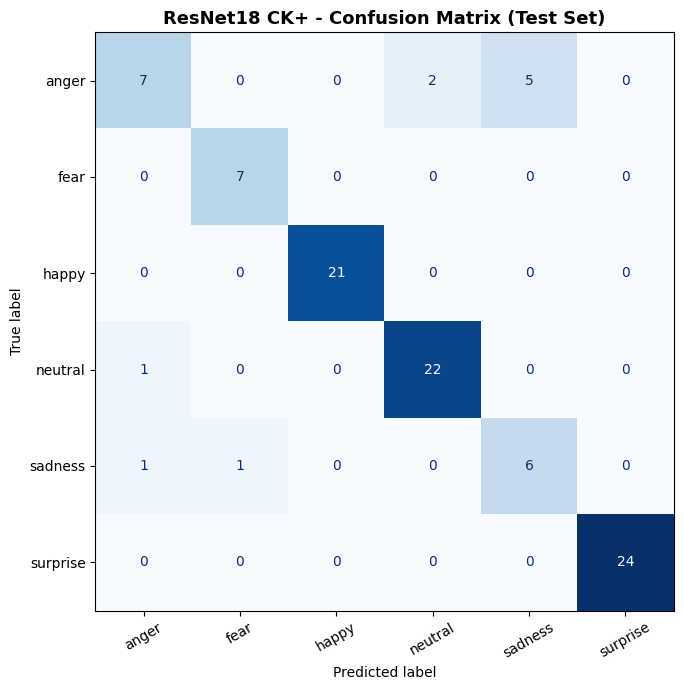

In [ ]:

conf_matrix = confusion_matrix(true_labels_np, predicted_labels,
                                labels=class_indices)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    conf_matrix, display_labels=EMOTION_CLASSES
).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)

ax.set_title('ResNet18 CK+ - Confusion Matrix (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet18_ckp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

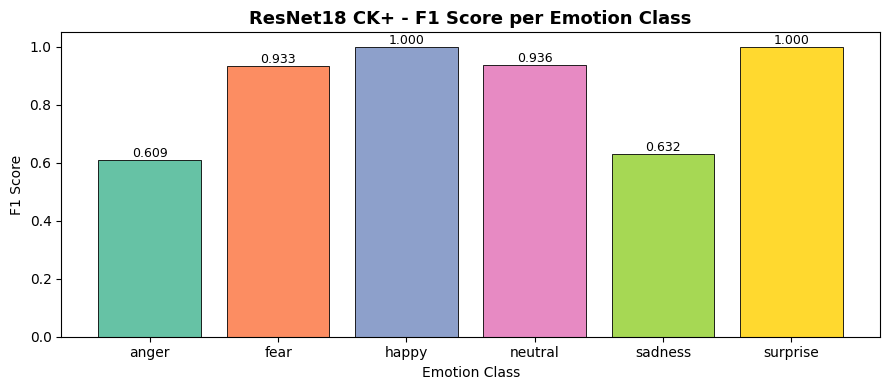

          precision  recall  f1-score  support
anger        0.7778  0.5000    0.6087     14.0
fear         0.8750  1.0000    0.9333      7.0
happy        1.0000  1.0000    1.0000     21.0
neutral      0.9167  0.9565    0.9362     23.0
sadness      0.5455  0.7500    0.6316      8.0
surprise     1.0000  1.0000    1.0000     24.0


In [ ]:

per_class_df = pd.DataFrame(report_dict).T.iloc[:NUM_EMOTIONS]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    EMOTION_CLASSES,
    per_class_df['f1-score'],
    color=sns.color_palette('Set2', NUM_EMOTIONS),
    edgecolor='black', linewidth=0.6
)
ax.set_title('ResNet18 CK+ - F1 Score per Emotion Class',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion Class')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
for bar, f1_val in zip(bars, per_class_df['f1-score']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            f1_val + 0.01, f'{f1_val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('resnet18_ckp_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(per_class_df[['precision','recall','f1-score','support']].round(4).to_string())

Correctly classified  : 87
Incorrectly classified: 10


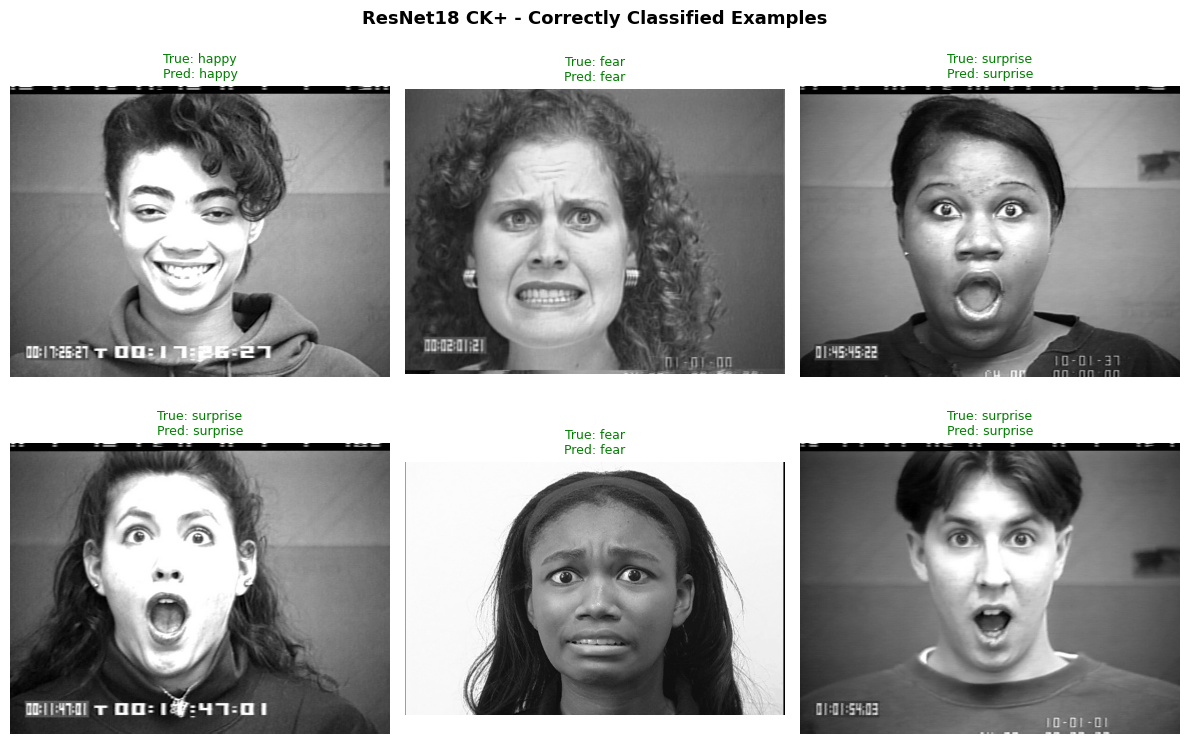

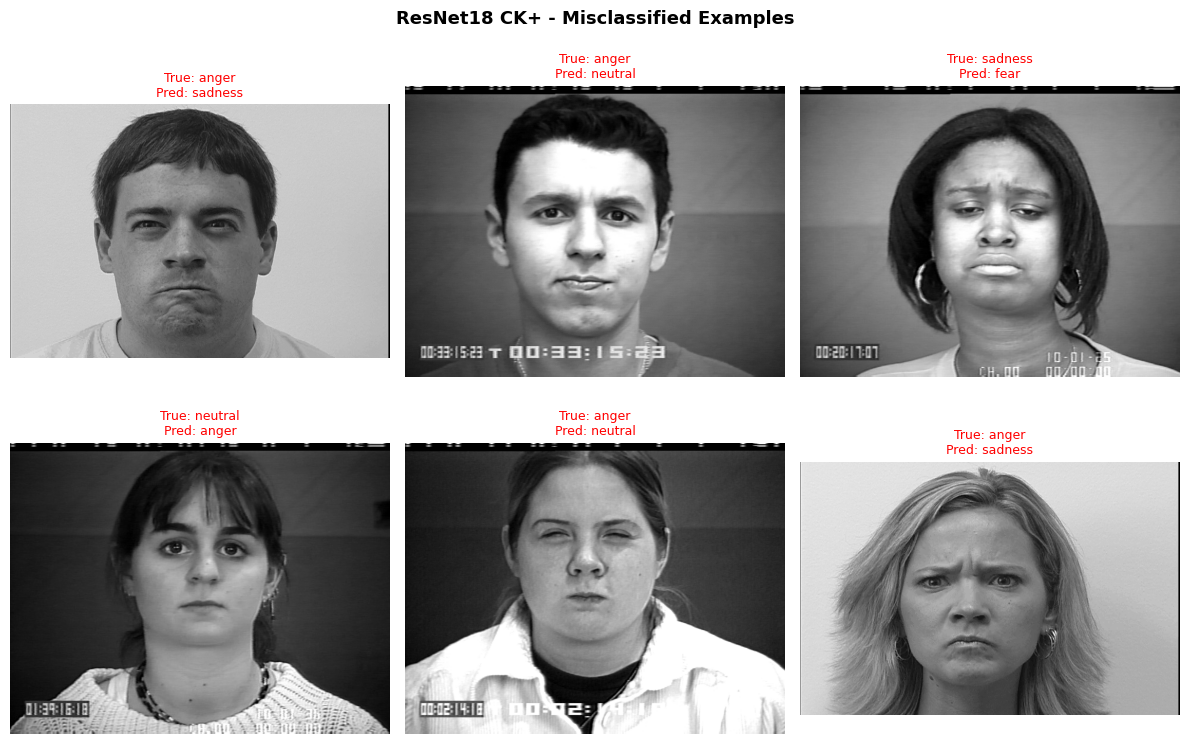

In [ ]:


correctly_classified   = [i for i in range(len(true_labels_np))
                           if true_labels_np[i] == predicted_labels[i]]
incorrectly_classified = [i for i in range(len(true_labels_np))
                           if true_labels_np[i] != predicted_labels[i]]

print(f'Correctly classified  : {len(correctly_classified)}')
print(f'Incorrectly classified: {len(incorrectly_classified)}')


def display_prediction_examples(sample_indices, figure_title,
                                 image_paths, num_examples=6,
                                 save_filename=None):
    selected = random.sample(sample_indices, min(num_examples, len(sample_indices)))
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(figure_title, fontsize=13, fontweight='bold')

    for ax, img_idx in zip(axes.flatten(), selected):
        img      = Image.open(image_paths[img_idx]).convert('L')
        true_cls = EMOTION_CLASSES[true_labels_np[img_idx]]
        pred_cls = EMOTION_CLASSES[predicted_labels[img_idx]]
        ok       = true_cls == pred_cls
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls}',
                     color='green' if ok else 'red', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    if save_filename:
        plt.savefig(save_filename, dpi=150, bbox_inches='tight')
    plt.show()


display_prediction_examples(
    correctly_classified,
    'ResNet18 CK+ - Correctly Classified Examples',
    test_paths,
    save_filename='resnet18_ckp_correct_predictions.png'
)

if incorrectly_classified:
    display_prediction_examples(
        incorrectly_classified,
        'ResNet18 CK+ - Misclassified Examples',
        test_paths,
        save_filename='resnet18_ckp_misclassified.png'
    )

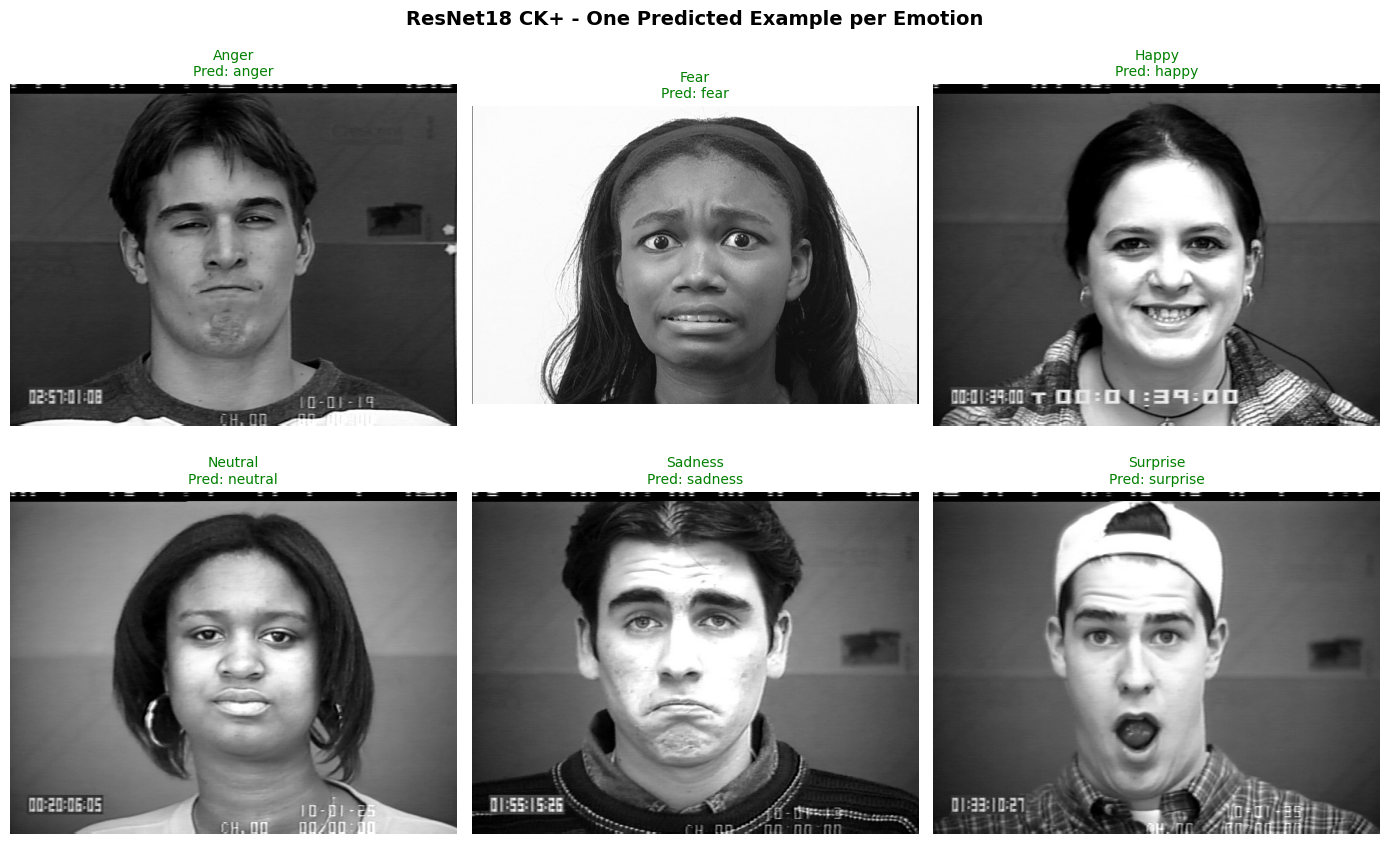

In [ ]:

# One correctly predicted example per emotion class.

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('ResNet18 CK+ - One Predicted Example per Emotion',
             fontsize=14, fontweight='bold')

for ax, emotion_idx in zip(axes.flatten(), range(NUM_EMOTIONS)):
    candidates = [
        i for i in range(len(true_labels_np))
        if true_labels_np[i] == emotion_idx
        and predicted_labels[i] == emotion_idx
    ]
    if not candidates:
        candidates = [i for i in range(len(true_labels_np))
                      if true_labels_np[i] == emotion_idx]
    if candidates:
        img_idx  = random.choice(candidates)
        img      = Image.open(test_paths[img_idx]).convert('L')
        pred_cls = EMOTION_CLASSES[predicted_labels[img_idx]]
        is_ok    = predicted_labels[img_idx] == emotion_idx
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f'{EMOTION_CLASSES[emotion_idx].capitalize()}\nPred: {pred_cls}',
            color='green' if is_ok else 'red', fontsize=10
        )
    ax.axis('off')

plt.tight_layout()
plt.savefig('resnet18_ckp_multi_emotion_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
output_filenames = [
    'resnet18_ckp_class_distribution.png',
    'resnet18_ckp_sample_images.png',
    'resnet18_ckp_training_curves.png',
    'resnet18_ckp_experiment_comparison.png',
    'resnet18_ckp_confusion_matrix.png',
    'resnet18_ckp_f1_per_class.png',
    'resnet18_ckp_correct_predictions.png',
    'resnet18_ckp_misclassified.png',
    'resnet18_ckp_multi_emotion_predictions.png',
    'resnet18_ckp_classification_report.txt',
]

for filename in output_filenames:
    src = Path(filename)
    dst = DRIVE_OUTPUT / filename

    if src.exists():
        if dst.exists():
            dst.unlink()
        shutil.copy2(src, dst)
        print(f'Saved: {filename}')
    else:
        print(f'Not found (run earlier cells first): {filename}')

# Collect the final evaluation metrics for the summary section.
macro_results = report_dict.get('macro avg', {})
loso_mean_f1 = np.mean(loso_f1_scores) if loso_f1_scores else float('nan')
loso_mean_acc = np.mean(loso_accuracies) if loso_accuracies else float('nan')

print('\n' + '=' * 62)
print('FINAL RESULTS SUMMARY - CK+ ResNet18 (Golden Pipeline)')
print('=' * 62)
print(f'Model               : ResNet18 (ImageNet pretrained)')
print(f'Input size          : 224x224')
print(f'Augmentation        : Golden Pipeline (flip+rot+affine+jitter)')
print(f'Optimiser           : AdamW  lr={PHASE2_LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler           : ReduceLROnPlateau (factor=0.1, patience=5)')
print(f'Dropout (FC head)   : {DROPOUT_RATE}')
print(f'Loss                : CrossEntropyLoss')
print(f'--- Standard Split + TTA ---')
print(f'Test Accuracy       : {test_accuracy * 100:.2f}%')
print(f'Macro Precision     : {macro_results.get("precision", 0):.4f}')
print(f'Macro Recall        : {macro_results.get("recall", 0):.4f}')
print(f'Macro F1            : {macro_results.get("f1-score", 0):.4f}')
print(f'--- LOSO (leakage-free) ---')
print(f'LOSO Mean Macro F1  : {loso_mean_f1:.4f}')
print(f'LOSO Mean Accuracy  : {loso_mean_acc:.4f}')
print('=' * 62)

Saved: resnet18_ckp_class_distribution.png
Saved: resnet18_ckp_sample_images.png
Saved: resnet18_ckp_training_curves.png
Saved: resnet18_ckp_experiment_comparison.png
Saved: resnet18_ckp_confusion_matrix.png
Saved: resnet18_ckp_f1_per_class.png
Saved: resnet18_ckp_correct_predictions.png
Saved: resnet18_ckp_misclassified.png
Saved: resnet18_ckp_multi_emotion_predictions.png
Saved: resnet18_ckp_classification_report.txt

FINAL RESULTS SUMMARY - CK+ ResNet18 (Golden Pipeline)
Model               : ResNet18 (ImageNet pretrained)
Input size          : 224x224
Augmentation        : Golden Pipeline (flip+rot+affine+jitter)
Optimiser           : AdamW  lr=0.0001  wd=0.01
Scheduler           : ReduceLROnPlateau (factor=0.1, patience=5)
Dropout (FC head)   : 0.5
Loss                : CrossEntropyLoss
--- Standard Split + TTA ---
Test Accuracy       : 89.69%
Macro Precision     : 0.8525
Macro Recall        : 0.8678
Macro F1            : 0.8516
--- LOSO (leakage-free) ---
LOSO Mean Macro F1  : 0.